# Plot wavetracks from QTRACK data
This notebook plots the wavetracks from each model simulation as an ensemble. The QTRACK tool was applied to each ensemble member, and two waves (Hurricane Paulette, and Tropical Strom Rene) are accessible. 

The first part of this notebook plots the wave of the user's selection, along with the user's selected ensemble set, whether control, fluxoff, or a decoupled experiment. 

The second part of this notebook plots both waves within the ensemble set, along with a comparison of these respective wave tracks from applying the tracker to ERA5 data.

In [1]:
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import pandas as pd
import os
import glob
from netCDF4 import Dataset


import xesmf as xe


from metpy.units import units
import geocat.viz as gv

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker 

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import wrf
from wrf import (to_np, interplevel, geo_bounds, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, destagger)

import metpy.calc as mpcalc
import seaborn as sns

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
plotsdir = '/glade/u/home/athornton/qtrack/'

In [2]:
## The following are lists to select each ensemble set and respective initialization time
variation = ['fluxon', 'rst_on24', 'rst_on36', 'rst_on48', '', 'fluxoff', '', '', 'obs']
init_times = ['0300','0303','0306',
             '0309','0312','0315',
             '0318','0321','0400']

In [3]:
#########################################
### MAKE SELECTIONS HERE
#set = 'Fluxes on'          # try: '24 hours without fluxes'
set_name = variation[1]     # try: variation[1]
wave = 'second'             # 'second' == Paulette or 'main' == Rene
title = '24 hrs decoupled'  # What will be displayed on main plot

In [4]:
# define plotting function
def create_fig():
    fig = plt.figure(figsize=(10,12))
    proj=ccrs.PlateCarree()
    
    ax = plt.axes(projection=proj)
    ax.set_extent([-70, -10, 0, 25],ccrs.PlateCarree())

    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=.5, edgecolor="black")
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=1.0)
    
    #gv.set_titles_and_labels(ax, lefttitle=" 600 hPa Zonal Winds", lefttitlefontsize=18)
    plt.title('AEW Tracks', loc='left', weight='bold', fontsize=14)
    plt.title(set_name, loc='right', fontsize=14)
    gl1 = ax.gridlines(crs=proj, linewidth=1, color='darkgray', draw_labels=True)
    gl1.top_labels = False
    gl1.right_labels = False
    gl1.xlocator = mticker.FixedLocator(np.arange(-90,40,5))
    gl1.ylocator = mticker.FixedLocator(np.arange(-5,40,5))
    gl1.xformatter = LongitudeFormatter(degree_symbol='')
    gl1.yformatter = LatitudeFormatter(degree_symbol='')
    
    colors = ['lightblue','skyblue','powderblue','lightskyblue','steelblue','lightsteelblue','cornflowerblue','royalblue']

    for ens,color in zip(init_times,colors):
        init_time = pd.to_datetime('2020-09-'+ens[0:2]+' '+ens[2:4]+':00:00')
        print(init_time)
        print('ensemble', init_time)
        end_time = pd.to_datetime('2020-09-09 12:00:00')
        df = xr.open_dataset('/glade/u/home/athornton/qtrack/'+wave+'_wave/'+wave+'_wave_track_'+set_name+'_'+ens+'.nc')
        times_list = pd.date_range(start=init_time, end=end_time, freq='6h')
        wave_track_lons = df.lon[-len(times_list):]
        wave_track_lats = df.lat[-len(times_list):]
        ax.plot(wave_track_lons, wave_track_lats, '-o', color=color)


    plt.tight_layout()
    #cb = plt.colorbar(vo_plot, ax=ax, orientation="horizontal", pad=.03, shrink=.8, aspect=30)
    #cb.set_label('Vorticity ($1$/$s$)', fontsize=14)
    
    outTPlotName= set_name+'_'+wave+'spaghetti.png'
    #plt.savefig(plotsdir+outTPlotName)



2020-09-03 00:00:00
ensemble 2020-09-03 00:00:00
2020-09-03 03:00:00
ensemble 2020-09-03 03:00:00
2020-09-03 06:00:00
ensemble 2020-09-03 06:00:00
2020-09-03 09:00:00
ensemble 2020-09-03 09:00:00
2020-09-03 12:00:00
ensemble 2020-09-03 12:00:00
2020-09-03 15:00:00
ensemble 2020-09-03 15:00:00
2020-09-03 18:00:00
ensemble 2020-09-03 18:00:00
2020-09-03 21:00:00
ensemble 2020-09-03 21:00:00


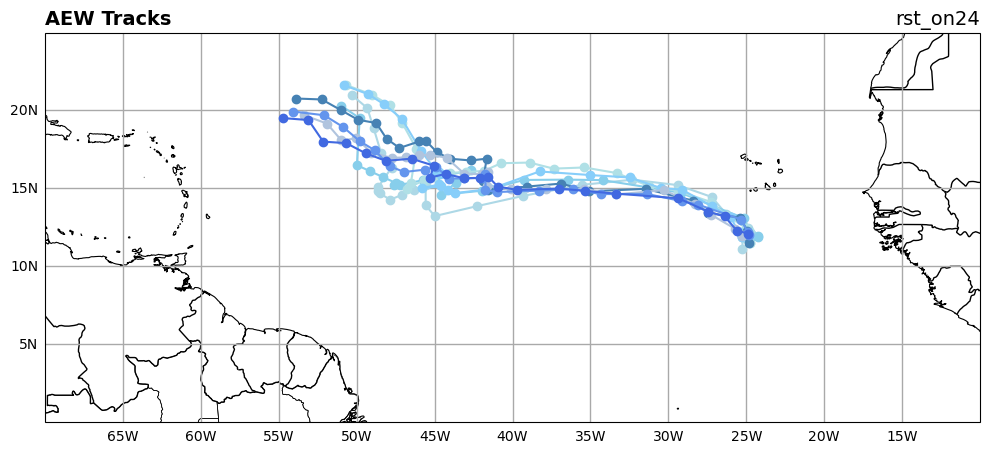

In [5]:
f = create_fig()

In [8]:
# define plotting function
def create_fig():
    fig = plt.figure(figsize=(10,12))
    proj=ccrs.PlateCarree()
    
    ax = plt.axes(projection=proj)
    ax.set_extent([-60, 0, 5, 25],ccrs.PlateCarree())

    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=.5, edgecolor="black")
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=1.0)
    
    #gv.set_titles_and_labels(ax, lefttitle=" 600 hPa Zonal Winds", lefttitlefontsize=18)
    plt.title('AEW Tracks', loc='left', weight='bold', fontsize=14)
    plt.title(set_name, loc='right', fontsize=14)
    gl1 = ax.gridlines(crs=proj, linewidth=1, color='darkgray', draw_labels=True)
    gl1.top_labels = False
    gl1.right_labels = False
    gl1.xlocator = mticker.FixedLocator(np.arange(-90,40,5))
    gl1.ylocator = mticker.FixedLocator(np.arange(-5,40,5))
    gl1.xformatter = LongitudeFormatter(degree_symbol='')
    gl1.yformatter = LatitudeFormatter(degree_symbol='')
    
    colors = ['lightblue','skyblue','powderblue','lightskyblue','steelblue','lightsteelblue','cornflowerblue','royalblue']

    wave = 'second'
    for ens,color in zip(init_times,colors):
        init_time = pd.to_datetime('2020-09-'+ens[0:2]+' '+ens[2:4]+':00:00')
        print(init_time)
        print('ensemble', init_time)
        end_time = pd.to_datetime('2020-09-09 12:00:00')
        df = xr.open_dataset('/glade/u/home/athornton/qtrack/'+wave+'_wave/'+wave+'_wave_track_'+set_name+'_'+ens+'.nc')
        times_list = pd.date_range(start=init_time, end=end_time, freq='6h')
        wave_track_lons = df.lon[-len(times_list):]
        wave_track_lats = df.lat[-len(times_list):]
        ax.plot(wave_track_lons, wave_track_lats, '-o', color=color, markersize=4.5, alpha=0.8)
    
    # Grab ERA5 data track for Paulette 
    df = xr.open_dataset('/glade/u/home/athornton/qtrack/'+wave+'_wave/'+wave+'_wave_track_obs.nc')
    times_list = pd.date_range(start='2020-09-03 00:00:00', end=end_time, freq='6h')
    wave_track_lons = df.lon[-len(times_list):]
    wave_track_lats = df.lat[-len(times_list):]
    ax.plot(wave_track_lons, wave_track_lats, '-o', color='black', label='Paulette', markersize=4.5)
    
    colors = ['salmon','indianred','firebrick','lightcoral','darksalmon','rosybrown','brown','darkred']

    wave = 'main'
    for ens,color in zip(init_times,colors):
        init_time = pd.to_datetime('2020-09-'+ens[0:2]+' '+ens[2:4]+':00:00')
        print(init_time)
        print('ensemble', init_time)
        end_time = pd.to_datetime('2020-09-09 12:00:00')
        df = xr.open_dataset('/glade/u/home/athornton/qtrack/'+wave+'_wave/'+wave+'_wave_track_'+set_name+'_'+ens+'.nc')
        times_list = pd.date_range(start=init_time, end=end_time, freq='6h')
        wave_track_lons = df.lon[-len(times_list):]
        wave_track_lats = df.lat[-len(times_list):]
        ax.plot(wave_track_lons, wave_track_lats, '-^', color=color, alpha=0.8)
    
    # Grab ERA5 data track for Rene 
    df = xr.open_dataset('/glade/u/home/athornton/qtrack/'+wave+'_wave/'+wave+'_wave_track_obs.nc')
    times_list = pd.date_range(start='2020-09-03 00:00:00', end=end_time, freq='6h')
    wave_track_lons = df.lon[-len(times_list):]
    wave_track_lats = df.lat[-len(times_list):]
    ax.plot(wave_track_lons, wave_track_lats, '-^', color='black', label='Rene')

    plt.tight_layout()
    #cb = plt.colorbar(vo_plot, ax=ax, orientation="horizontal", pad=.03, shrink=.8, aspect=30)
    #cb.set_label('Vorticity ($1$/$s$)', fontsize=14)

    plt.legend()
    outTPlotName= 'both_waves_spaghetti_'+set_name+'.png'
    #plt.savefig(plotsdir+outTPlotName)



2020-09-03 00:00:00
ensemble 2020-09-03 00:00:00
2020-09-03 03:00:00
ensemble 2020-09-03 03:00:00
2020-09-03 06:00:00
ensemble 2020-09-03 06:00:00
2020-09-03 09:00:00
ensemble 2020-09-03 09:00:00
2020-09-03 12:00:00
ensemble 2020-09-03 12:00:00
2020-09-03 15:00:00
ensemble 2020-09-03 15:00:00
2020-09-03 18:00:00
ensemble 2020-09-03 18:00:00
2020-09-03 21:00:00
ensemble 2020-09-03 21:00:00
2020-09-03 00:00:00
ensemble 2020-09-03 00:00:00
2020-09-03 03:00:00
ensemble 2020-09-03 03:00:00
2020-09-03 06:00:00
ensemble 2020-09-03 06:00:00
2020-09-03 09:00:00
ensemble 2020-09-03 09:00:00
2020-09-03 12:00:00
ensemble 2020-09-03 12:00:00
2020-09-03 15:00:00
ensemble 2020-09-03 15:00:00
2020-09-03 18:00:00
ensemble 2020-09-03 18:00:00
2020-09-03 21:00:00
ensemble 2020-09-03 21:00:00


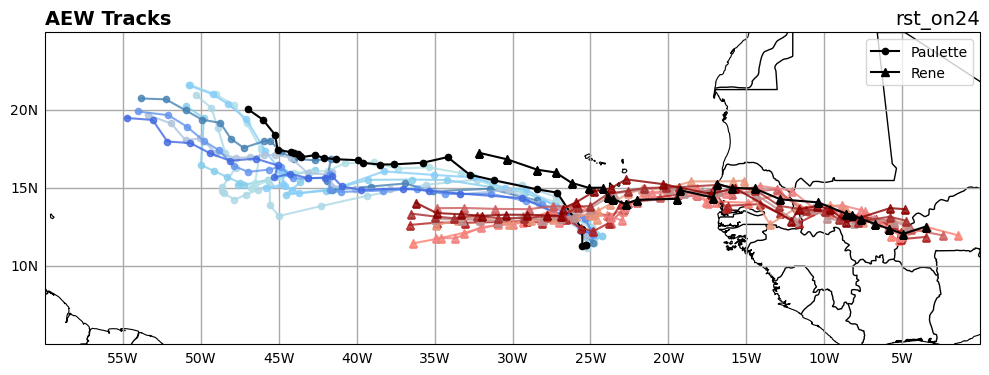

In [9]:
f = create_fig()